Veri yüklendi. Toplam satır sayısı: 17

------------------HOŞ GELDİNİZ--------------------
Size en uygun şirketi önerebilmemiz için ekrana gelen menüden seçiminizi yapınız.
Başlamak için Enter'a basınız.


Hizmet almak istediğiniz alanları seçiniz:
1. Dijital Pazarlama Danışmanlığı
2. Dönüşüm Optimizasyonu
3. E posta Pazarlama
4. E-Ticaret Danışmanlığı
5. Finans Yönetimi
6. Google Reklam Danışmanlığı
7. Kurumsal Hizmet Yönetimi
8. Marka Yönetimi
9. Mobil Uygulama Geliştiriciliği
10. Müşteri İlişkileri Yönetimi
11. Pazar Analizi/Rakip Analizi/Veri Analizi
12. Pazarlama Yönetimi
13. Proje Yönetimi
14. Raporlama Otomasyonu
15. Reklam Yönetimi
16. Robatik Süreç Otomasyonu
17. Rota Optimizasyonu
18. SEO Danışmanlığı
19. Satış Danışmanlığı
20. Sosyal Medya Danışmanlığı
21. Sosyal Medya Yönetimi
22. Stok/Satış/Sipariş Yönetimi
23. Veri Yönetimi
24. Web Analizi
25. Web Tasarım/Geliştirme
26. İlişkilendirme Modelleri
27. İnflucer Marketing
28. İş Süreçleri Otomasyonu
Seçiminizin numarasını giri

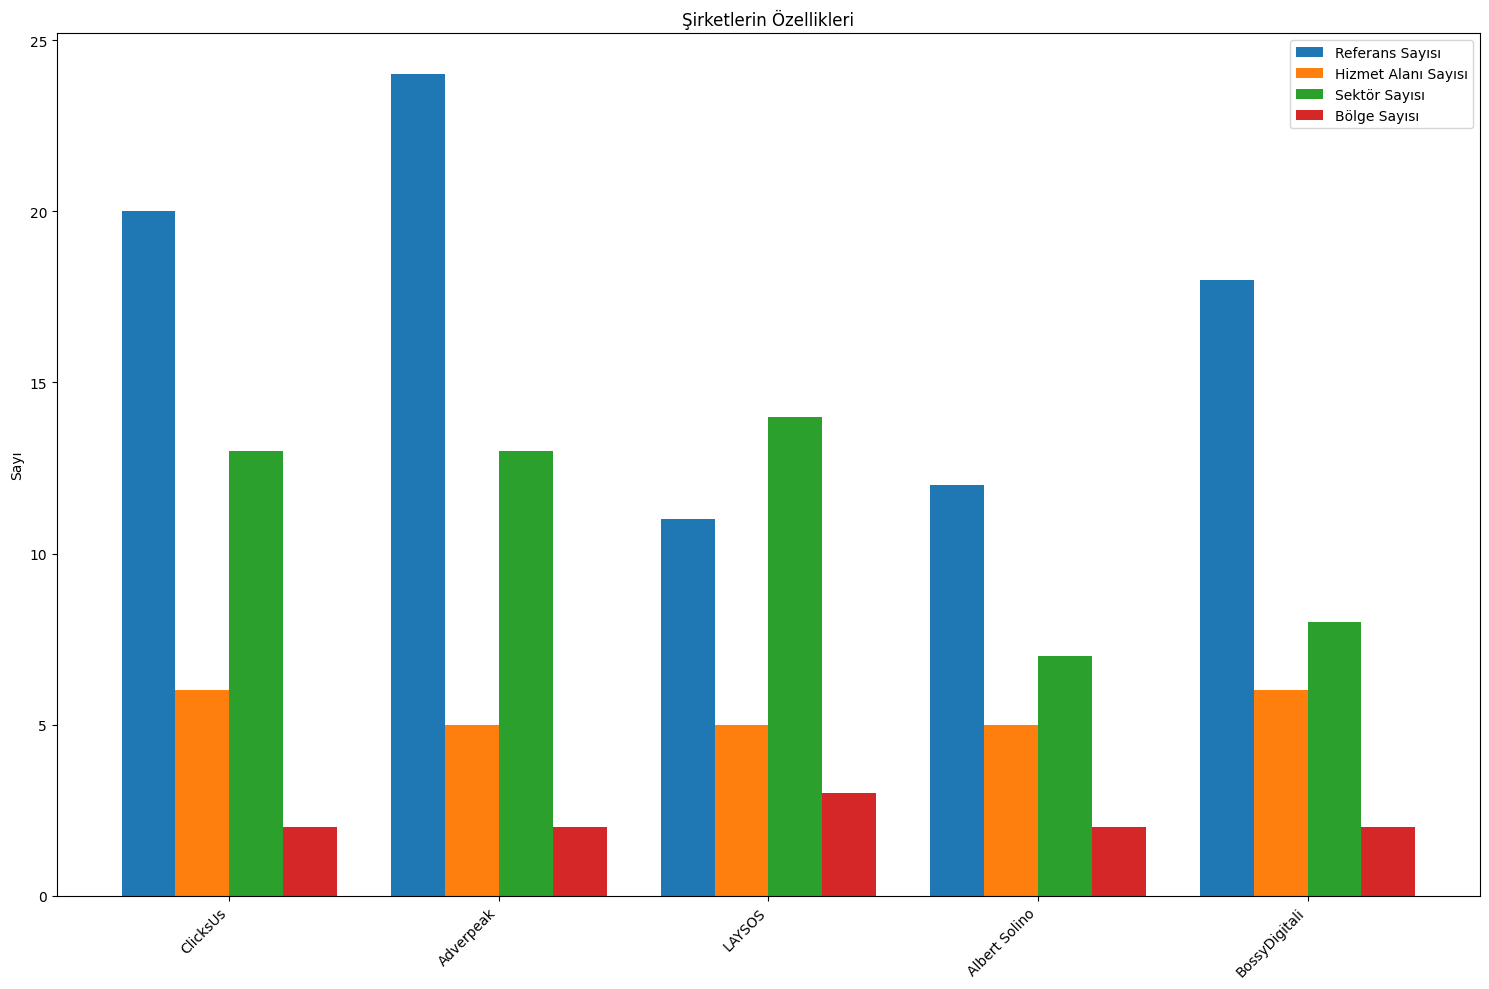

In [24]:
import pandas as pd
import re
import matplotlib.pyplot as plt

try:
    dosya_yolu = "denemeee.xlsx"
    xls = pd.ExcelFile(dosya_yolu)
except FileNotFoundError:
    print(f"Hata: {dosya_yolu} dosyası bulunamadı.")
    exit()
except Exception as e:
    print(f"Excel dosyası okunurken bir hata oluştu: {e}")
    exit()


tum_veri = pd.DataFrame()
for sayfa_adi in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sayfa_adi)
    df['ŞİRKET ADI'] = df.get('ŞİRKET ADI', sayfa_adi)  # Şirket adını ekle veya varsayılan olarak sheet_name kullan
    tum_veri = pd.concat([tum_veri, df], ignore_index=True) # parametre, index numaralarının yeniden sıralanmasını sağlar

print("Veri yüklendi. Toplam satır sayısı:", len(tum_veri))

# Sınıf yapısı ile filtreleme işlemi
class VeriFiltreleyici:
    def __init__(self, veri):    #constructor
        self.veri = veri

    def ayir_ve_tekrarini_azalt(self, sutun):   #tekrarları kırptık
        elemanlar = []
        for eleman in sutun.dropna().unique():
            elemanlar.extend([s.strip() for s in eleman.split(',')])    #boşlukları temizledik, virgülle ayırdık
        return sorted(set(elemanlar))    #sıralı ve temiz bir liste

    def eslesen_sirketleri_bul(self, hizmetler, bölgeler, sektör):
        print(f"Aranan: Hizmet: {', '.join(hizmetler)}, Bölge: {', '.join(bölgeler)}, Sektör: {sektör}")

        eşleşmeler = self.veri[                      #veri setinde kriterlere uyan satırları döndürecek
            self.veri.apply(lambda satır: # her bir satırı alır ve bu satır üzerinde kriterleri kontrol eder.
                            any(any(re.search(re.escape(hizmet), str(değer), re.IGNORECASE) for hizmet in hizmetler) for değer in satır) and       #re arama eşleştirme
                            any(any(re.search(re.escape(bölge), str(değer), re.IGNORECASE) for bölge in bölgeler) for değer in satır) and
                            any(re.search(re.escape(sektör), str(değer), re.IGNORECASE) for değer in satır), axis=1) #axis satır bazında,
        ]

        if eşleşmeler.empty:
            return pd.DataFrame({"Sonuç": ["Seçtiğiniz kriterlerin tümünü karşılayan bir şirket bulunamadı."]})

        return eşleşmeler[['ŞİRKET ADI', 'REFANSLAR', 'İLETİŞİM', 'SEKTÖRLER', 'HİZMET VERİLEN ALANLAR', 'BÖLGE']]

def menüyü_göster():
    print("\n------------------HOŞ GELDİNİZ--------------------")
    print("Size en uygun şirketi önerebilmemiz için ekrana gelen menüden seçiminizi yapınız.")
    print("Başlamak için Enter'a basınız.")
    input()

def birden_fazla_seçim_al(options, prompt):
    print(f"\n{prompt}")
    for i, seçenek in enumerate(options, 1):
        print(f"{i}. {seçenek}")
    seçimler = []
    while True:
        seçim = input("Seçiminizin numarasını giriniz (birden fazla seçim için numaraları virgülle ayırın, bitirmek için 'q' yazın): ")
        if seçim.lower() == 'q':
            break
        try:
            seçim_numaraları = [int(s.strip()) for s in seçim.split(',')]
            geçerli_seçimler = [options[num - 1] for num in seçim_numaraları if 1 <= num <= len(options)]
            seçimler.extend(geçerli_seçimler)
            print(f"Şu ana kadar seçtikleriniz: {', '.join(seçimler)}")
        except ValueError:
            print("Geçersiz giriş. Lütfen sayıları virgülle ayırarak girin.")
    return seçimler

# Program akışı
menüyü_göster()

veri_filtreleyici = VeriFiltreleyici(tum_veri)

hizmetler = veri_filtreleyici.ayir_ve_tekrarini_azalt(tum_veri['HİZMET VERİLEN ALANLAR'])
hizmet_seçimleri = birden_fazla_seçim_al(hizmetler, "Hizmet almak istediğiniz alanları seçiniz:")

bölgeler = veri_filtreleyici.ayir_ve_tekrarini_azalt(tum_veri['BÖLGE'])
bölge_seçimleri = birden_fazla_seçim_al(bölgeler, "Hizmet almak istediğiniz bölgeleri seçiniz:")

sektörler = veri_filtreleyici.ayir_ve_tekrarini_azalt(tum_veri['SEKTÖRLER'])
sektör_seçimi = birden_fazla_seçim_al(sektörler, "Hizmet almak istediğiniz sektörü seçiniz:")[0]  # Sadece bir sektör seçimi

sonuç = veri_filtreleyici.eslesen_sirketleri_bul(hizmet_seçimleri, bölge_seçimleri, sektör_seçimi)

# Grafik oluşturma fonksiyonu
def plot_sirket_ozellikleri(veri):
    # Şirket adlarını al
    sirketler = veri['ŞİRKET ADI'].unique()

    # Her bir şirket için referans, hizmet alanı, sektör ve bölge sayısını hesapla
    referans_sayilari = []
    hizmet_sayilari = []
    sektor_sayilari = []
    bolge_sayilari = []

    for sirket in sirketler:
        # İlgili şirketin verilerini filtrele
        sirket_veri = veri[veri['ŞİRKET ADI'] == sirket]

        # Referans sayısını hesapla
        referanslar = str(sirket_veri['REFANSLAR'].iloc[0]).split(', ')
        referans_sayilari.append(len([r for r in referanslar if r.strip()]))  # Boş olmayan referansları say

        # Hizmet verilen alanların sayısını hesapla
        hizmetler = str(sirket_veri['HİZMET VERİLEN ALANLAR'].iloc[0]).split(', ')
        hizmet_sayilari.append(len([h for h in hizmetler if h.strip()]))  # Boş olmayan hizmetleri say

        # Sektör sayısını hesapla
        sektorler = str(sirket_veri['SEKTÖRLER'].iloc[0]).split(', ')
        sektor_sayilari.append(len([s for s in sektorler if s.strip()]))  # Boş olmayan sektörleri say

        # Bölge sayısını hesapla
        bolgeler = str(sirket_veri['BÖLGE'].iloc[0]).split(', ')
        bolge_sayilari.append(len([b for b in bolgeler if b.strip()]))  # Boş olmayan bölgeleri say

    # X ekseni için indeksler oluştur
    x = range(len(sirketler))
    width = 0.2  # Bar genişliği

    # Grafik boyutunu şirket sayısına göre dinamik olarak ayarla
    fig_width = max(15, len(sirketler) * 2)  # Minimum genişlik 15, her şirket için 2 birim ekle
    fig_height = 10  # Sabit yükseklik

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # Grafik oluştur

    # Bar grafikleri oluştur
    ax.bar([i - 1.5*width for i in x], referans_sayilari, width, label='Referans Sayısı')
    ax.bar([i - 0.5*width for i in x], hizmet_sayilari, width, label='Hizmet Alanı Sayısı')
    ax.bar([i + 0.5*width for i in x], sektor_sayilari, width, label='Sektör Sayısı')
    ax.bar([i + 1.5*width for i in x], bolge_sayilari, width, label='Bölge Sayısı')

    # Eksen ve grafik başlıklarını ayarla
    ax.set_ylabel('Sayı')  # Y ekseni etiketi
    ax.set_title('Şirketlerin Özellikleri')  # Grafik başlığı
    ax.set_xticks(x)  # X ekseni değerleri
    ax.set_xticklabels(sirketler, rotation=45, ha='right')  # X ekseni etiketleri (şirket adları)
    ax.legend()  # Grafik açıklaması (legend)

    plt.tight_layout()  # Grafik bileşenlerinin birbirine girmesini önle
    plt.show()  # Grafiği göster

print("\nSonuç:")
if not sonuç.empty and 'ŞİRKET ADI' in sonuç.columns:
    for i, (_, şirket_verisi) in enumerate(sonuç.iterrows(), 1):
        print(f"\n{i}. {şirket_verisi['ŞİRKET ADI']}:")

        print("   REFANSLAR:")
        referanslar = str(şirket_verisi['REFANSLAR']).split(', ')
        for ref in referanslar:
            print(f"   - {ref.strip()}")

        print("   İLETİŞİM:")
        iletişim_bilgileri = str(şirket_verisi['İLETİŞİM']).split(', ')
        for bilgi in iletişim_bilgileri:
            print(f"   - {bilgi.strip()}")

        print("   SEKTÖRLER:")
        sektörler = str(şirket_verisi['SEKTÖRLER']).split(', ')
        for sektör in sektörler:
            print(f"   - {sektör.strip()}")

    # Grafik oluştur
    plot_sirket_ozellikleri(sonuç)
else:
    print(sonuç['Sonuç'].iloc[0])